In [44]:
import tensorflow as tf
import tensorflow_datasets as tfds

(ds_train, ds_val, ds_test), ds_info = tfds.load(
    'oxford_flowers102',
    split=['train', 'validation', 'test'],
    as_supervised=True,
    with_info=True
)

In [45]:
print(ds_info)

tfds.core.DatasetInfo(
    name='oxford_flowers102',
    full_name='oxford_flowers102/2.1.1',
    description="""
    The Oxford Flowers 102 dataset is a consistent of 102 flower categories commonly
    occurring in the United Kingdom. Each class consists of between 40 and 258
    images. The images have large scale, pose and light variations. In addition,
    there are categories that have large variations within the category and several
    very similar categories.
    
    The dataset is divided into a training set, a validation set and a test set. The
    training set and validation set each consist of 10 images per class (totalling
    1020 images each). The test set consists of the remaining 6149 images (minimum
    20 per class).
    
    Note: The dataset by default comes with a test size larger than the train size.
    For more info see this
    [issue](https://github.com/tensorflow/datasets/issues/3022).
    """,
    homepage='https://www.robots.ox.ac.uk/~vgg/data/flowers/102

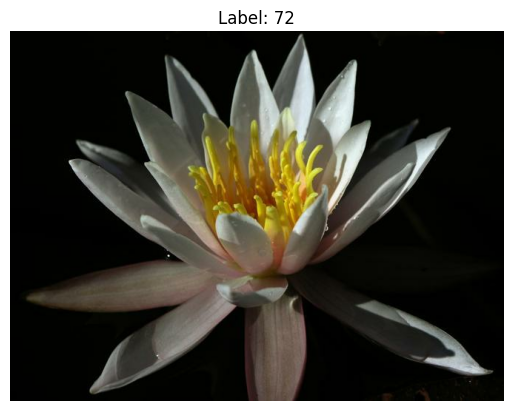

In [46]:
import matplotlib.pyplot as plt

for image, label in ds_train.take(1):
    plt.imshow(image)
    plt.title(f"Label: {label}")
    plt.axis("off")

In [47]:
IMG_SIZE = 224

In [48]:
def preprocess(image, label):
    # Αλλαγή μεγέθους
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))

    # Κανονικοποίηση pixel (0–255 → 0–1)
    image = image / 255.0

    return image, label

In [49]:
ds_train_prep = ds_train.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
ds_val_prep   = ds_val.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
ds_test_prep  = ds_test.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)

In [50]:
for image, label in ds_train_prep.take(1):
    print("Shape:", image.shape)
    print("Min pixel:", tf.reduce_min(image).numpy())
    print("Max pixel:", tf.reduce_max(image).numpy())

Shape: (224, 224, 3)
Min pixel: 0.0
Max pixel: 0.991203


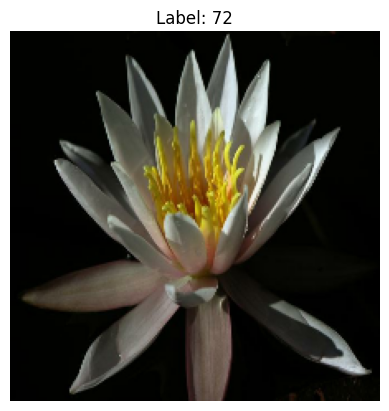

In [51]:
import matplotlib.pyplot as plt

for image, label in ds_train_prep.take(1):
    plt.imshow(image)
    plt.title(f"Label: {label}")
    plt.axis("off")

In [52]:
BATCH_SIZE = 32

ds_train_ready = ds_train_prep.shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
ds_val_ready   = ds_val_prep.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
ds_test_ready  = ds_test_prep.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [ ]:
model_cnn = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dense(102, activation='softmax')
])

In [54]:
model_cnn.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │    22,151,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 102)            │        26,214 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,270,886 (84.96 MB)

 Trainable params: 22,270,886 (84.96 MB)

 Non-trainable params: 0 (0.00 B)

In [55]:
model_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history_cnn = model_cnn.fit(
    ds_train_ready,
    validation_data=ds_val_ready,
    epochs=10
)

Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 12s 221ms/step - accuracy: 0.0167 - loss: 4.9400 - val_accuracy: 0.0098 - val_loss: 4.5618
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 111ms/step - accuracy: 0.0265 - loss: 4.4500 - val_accuracy: 0.0225 - val_loss: 4.3316
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 10s 112ms/step - accuracy: 0.1088 - loss: 3.8386 - val_accuracy: 0.0735 - val_loss: 4.3393
Epoch 4/10
25/32 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.4873 - loss: 2.3751

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history_cnn.history['accuracy'], label='train acc')
plt.plot(history_cnn.history['val_accuracy'], label='val acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [ ]:
test_loss, test_acc = model_cnn.evaluate(ds_test_ready)
print("Test accuracy:", test_acc)

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np

y_true = []
y_pred = []

for images, labels in ds_test_ready:
    predictions = model_cnn.predict(images, verbose=0)
    y_pred.extend(np.argmax(predictions, axis=1))
    y_true.extend(labels.numpy())

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, cmap='Blues')
plt.title("Confusion Matrix - CNN")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [ ]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

In [ ]:
model_tl = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dense(102, activation='softmax')
])

In [ ]:
model_tl.summary()

In [ ]:
model_tl.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history_tl = model_tl.fit(
    ds_train_ready,
    validation_data=ds_val_ready,
    epochs=10
)

In [ ]:
test_loss_tl, test_acc_tl = model_tl.evaluate(ds_test_ready)
print(f"Test accuracy (Transfer Learning): {test_acc_tl:.4f}")

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(history_tl.history['accuracy'], label='Train Accuracy')
plt.plot(history_tl.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('MobileNetV2 Accuracy')
plt.show()

In [ ]:
base_model.trainable = True

# Πάγωμα όλων εκτός από τα τελευταία 30 layers
for layer in base_model.layers[:-30]:
    layer.trainable = False

In [ ]:
for layer in base_model.layers[-5:]:
    print(layer.name, layer.trainable)

In [ ]:
model_ft = model_tl  # συνεχίζουμε από το ίδιο μοντέλο

model_ft.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history_ft = model_ft.fit(
    ds_train_ready,
    validation_data=ds_val_ready,
    epochs=10
)

In [ ]:
test_loss_ft, test_acc_ft = model_ft.evaluate(ds_test_ready)
print(f"Test accuracy (Fine-tuned): {test_acc_ft:.4f}")

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(history_ft.history['accuracy'], label='Train Accuracy')
plt.plot(history_ft.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Fine-tuned MobileNetV2 Accuracy')
plt.show()

In [ ]:
def plot_history(histories, labels, metric):
    plt.figure(figsize=(10,6))

    for history, label in zip(histories, labels):
        plt.plot(history.history[metric], label=f"{label} - train")
        plt.plot(history.history["val_" + metric], linestyle="--", label=f"{label} - val")

    plt.xlabel("Epochs")
    plt.ylabel(metric.capitalize())
    plt.title(metric.capitalize() + " curves")
    plt.legend()
    plt.grid(True)
    plt.show()


models_histories = [history_cnn, history_tl, history_ft]
labels = ["Simple CNN", "MobileNetV2", "Fine-tuned MobileNetV2"]

# Accuracy
plot_history(models_histories, labels, "accuracy")

# Loss
plot_history(models_histories, labels, "loss")


In [ ]:
{
        "cell_type": "code",
        "execution_count": None,
        "outputs": [],
        "metadata": {
          "id": "e2769b9e0005"
        },
        "source": [
          "!pip install git+https://github.com/google/starthinker\n"
        ]
     },